# Phase Corection
### General Story:
We got the phase and magnitude of an averaged signal from Phase on the Fly, now we want to detect frequency for PLL locking. In our case what we want is to detect the frequency difference from our expected and change to match that

We are assuming that the register is giving us an average of the entire adc read such that:
$$tan^{-1}(\frac{I}{Q}) = tan^{-1}(\frac{\int cos(\omega t + \phi)}{\int cos(\omega t + \phi + \frac{\pi}{4})})$$

Where by using some math and trig identities you get:

$$tan^{-1}(\frac{cos(\omega t + \phi)}{cos(\omega t + \phi + \frac{\pi}{4})}) = \phi$$

considering that 
$$\omega = \frac{\Delta \phi}{\Delta t}$$

we need two values of $\phi$ and the starting or stopping points of our read

In [1]:
#imports
from qick import *
from qick.asm_v2 import *
%matplotlib inline
import matplotlib.pyplot as plt
import os
import git  # pip install gitpython


In [2]:
#this block is for running a command on the RFsoC assuming you are 
#running one of the jupyter notebooks on the device but from a separate computer/visual studio code:

dir = os.getcwd()
print(dir)
print(os.listdir())
# print(os.getcwd())
# os.system("pip install gitpython")

/home/xilinx/jupyter_notebooks
['qick', 'user_implementation', 'getting_started', 'common', 'amo_qick', '.ipynb_checkpoints', 'Welcome to Pynq.ipynb']


In [3]:
#this will pull from the github to make sure you have the most current updates

import git  # pip install gitpython
print(os.listdir())
if 'amo_qick' in os.listdir():
        print("getting into fork")
        os.chdir('amo_qick')
dir = os.getcwd()
print(dir)
g = git.cmd.Git(dir)
g.pull()

['qick', 'user_implementation', 'getting_started', 'common', 'amo_qick', '.ipynb_checkpoints', 'Welcome to Pynq.ipynb']
getting into fork
/home/xilinx/jupyter_notebooks/amo_qick


'Updating 9c3da11..c3ddbd7\nFast-forward\n tests/Phase_Correction.ipynb       | 392 +++++++++++++-----\n tests/Phase_OnTheFly.ipynb         | 828 +++++++++++--------------------------\n tests/data_imgs/closer_phase.png   | Bin 0 -> 11283 bytes\n tests/data_imgs/grid_pic.png       | Bin 0 -> 12380 bytes\n tests/data_imgs/magn_error.png     | Bin 0 -> 11626 bytes\n tests/data_imgs/phase_from_reg.png | Bin 0 -> 14492 bytes\n 6 files changed, 531 insertions(+), 689 deletions(-)\n create mode 100644 tests/data_imgs/closer_phase.png\n create mode 100644 tests/data_imgs/grid_pic.png\n create mode 100644 tests/data_imgs/magn_error.png\n create mode 100644 tests/data_imgs/phase_from_reg.png'

In [4]:


#This line is to sync to an external clock which needs to be 10 Mhz
#this line currently loads tproc1 firmware and is just to make sure everything is loaded properly
#soc = QickSoc(external_clk=True)

dir = os.getcwd()
print(dir)
#this line downloads the new hardware (just make sure thats what you want)
#soc = QickSoc()
#soc = QickSoc(bitfile =f'{dir}/tests/d_1.bit', download=True)
#as of Jan 2026: 
#rfsoc_board = most recently published bit, 
# ADC_0 = Self built file that connects adc port 0 to tproc 1
# d_1 = self built that puts a cordic loop on adc port 0 for phase analysis 
soc = QickSoc(bitfile =f'{dir}/tests/rf_board_firmware/d_1.bit', download=True)
soccfg = soc
print(soccfg)


/home/xilinx/jupyter_notebooks/amo_qick
RFSoC PLLs are not locked, configuring reference clock chips (this is normal after power cycle)
LMK04828 clock reference = 245.760 MHz, LMX2594 clock synth = 491.520 MHz
QICK running on ZCU216, software version 0.2.388

Firmware configuration (built Fri Apr  3 16:28:09 2026):

	Global clocks (MHz): tProc dispatcher timing 430.080, RF reference 245.760
	Groups of related clocks: [tProc core clock, tProc timing clock, DAC tile 1, DAC tile 2, DAC tile 3], [DAC tile 0], [ADC tile 1, ADC tile 2]

	16 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 65536 complex samples (6.838 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 0 is 0_228 on JHC1, or QICK box DAC port 0
	1:	axis_signal_gen_v6 - fs=9584.640 Msps, fabric=599.040 MHz
		envelope memory: 16384 complex samples (1.709 us)
		32-bit DDS, range=9584.640 MHz
		DAC tile 0, blk 1 is 1_228 on JHC2, or QICK box DAC port 1
	2:	axis_signal_

#### Uncorrected from Laser

  0%|          | 0/1 [00:00<?, ?it/s]

phase offset: -13.966370600719785
buffered readout: [ 772. -192.]
feedback readout: [       902 -180920129]


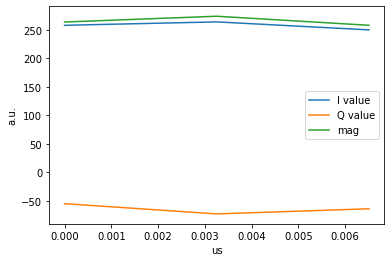

In [213]:
class ReadProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'], 
                      )

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
        # send the config to the dynamic RO
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.wait_auto(cfg['read_wait'])
        self.read_input(ro_ch=cfg['ro_ch'])
        self.write_dmem(addr=0, src='s_port_l')
        self.write_dmem(addr=1, src='s_port_h')

config = {'gen_ch': 0,
          'ro_ch': 10,
          'freq': 124,
          #last delay for pd was .545 us (plus the 0.4 of the original offset)
          'trig_time': 1,
          'read_wait': 0.1,
          'ro_len': .01,
          'pulse_len': 0.1,
          'pulse_phase': 0,
          'ro_phase': 0,
          'gain': 1.0
         }

# prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
# iq_list = prog.acquire(soc, rounds=1, progress=False)
# phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
# config['ro_phase'] = -phase_offset

prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

phase_offset = np.angle(iq_list[0].sum(axis=0).dot([1,1j]), deg=True)
print("phase offset:", phase_offset)

print("buffered readout:", iq_list[0].sum(axis=0))
print("feedback readout:", soc.read_mem(2,'dmem'))

### Uncorrected reference from different RF port
This isnt technically perfect but a good starting spot to see if we can correct to a specific phase value


  0%|          | 0/1 [00:00<?, ?it/s]

phase offset: -40.224039006887494
buffered readout: [ 3962. -3351.]
feedback readout: [ 4004 -3433]


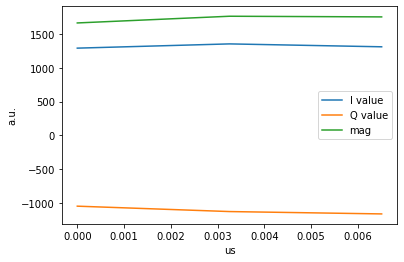

In [206]:
class ReadProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'], 
                      )

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
        # send the config to the dynamic RO
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.wait_auto(cfg['read_wait'])
        self.read_input(ro_ch=cfg['ro_ch'])
        self.write_dmem(addr=0, src='s_port_l')
        self.write_dmem(addr=1, src='s_port_h')

config = {'gen_ch': 1,
          'ro_ch': 0,
          'freq': 124,
          #last delay for pd was .545 us (plus the 0.4 of the original offset)
          'trig_time': 0.45,
          'read_wait': 0.1,
          'ro_len': .01,
          'pulse_len': 0.1,
          'pulse_phase': 0,
          'ro_phase': 0,
          'gain': 1.0
         }

# prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
# iq_list = prog.acquire(soc, rounds=1, progress=False)
# phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
# config['ro_phase'] = -phase_offset

prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

phase_offset = np.angle(iq_list[0].sum(axis=0).dot([1,1j]), deg=True)
print("phase offset:", phase_offset)

print("buffered readout:", iq_list[0].sum(axis=0))
print("feedback readout:", soc.read_mem(2,'dmem'))

Lets see if we can correct to a static phase value: -3433 -> -40 degrees

In [ ]:
class ReadProgram(AveragerProgramV2):
    def _initialize(self, cfg):
        ro_ch = cfg['ro_ch']
        gen_ch = cfg['gen_ch']
        
        self.declare_gen(ch=gen_ch, nqz=1)
        self.declare_readout(ch=ro_ch, length=cfg['ro_len'])

        self.add_pulse(ch=gen_ch, name="mypulse", ro_ch=ro_ch, 
                       style="const", 
                       freq=cfg['freq'], 
                       length=cfg['pulse_len'],
                       phase=cfg['pulse_phase'],
                       gain=cfg['gain'], 
                      )

        self.add_readoutconfig(ch=ro_ch, name="myro", freq=cfg['freq'], gen_ch=gen_ch, phase=cfg['ro_phase'])
        # send the config to the dynamic RO
        self.send_readoutconfig(ch=ro_ch, name="myro", t=0)
        
    def _body(self, cfg):
        self.pulse(ch=cfg['gen_ch'], name="mypulse", t=0)
        self.trigger(ros=[cfg['ro_ch']], pins=[0], t=cfg['trig_time'])
        self.wait_auto(cfg['read_wait'])
        self.read_input(ro_ch=cfg['ro_ch'])
        self.write_dmem(addr=0, src='s_port_l')
        self.write_dmem(addr=1, src='s_port_h')

config = {'gen_ch': 1,
          'ro_ch': 0,
          'freq': 124,
          #last delay for pd was .545 us (plus the 0.4 of the original offset)
          'trig_time': 0.45,
          'read_wait': 0.1,
          'ro_len': .01,
          'pulse_len': 0.1,
          'pulse_phase': 0,
          'ro_phase': 0,
          'gain': 1.0
         }

# prog = ReadProgram(soccfg, reps=100, final_delay=0.5, cfg=config)
# iq_list = prog.acquire(soc, rounds=1, progress=False)
# phase_offset = np.angle(iq_list[0][0].dot([1,1j]), deg=True)
# config['ro_phase'] = -phase_offset

prog = ReadProgram(soccfg, reps=1, final_delay=0.5, cfg=config)

iq_list = prog.acquire_decimated(soc, rounds=1)
t = prog.get_time_axis(ro_index=0)

plt.plot(t, iq_list[0][:,0], label="I value")
plt.plot(t, iq_list[0][:,1], label="Q value")
plt.plot(t, np.abs(iq_list[0].dot([1,1j])), label="mag")
plt.legend()
plt.ylabel("a.u.")
plt.xlabel("us");

phase_offset = np.angle(iq_list[0].sum(axis=0).dot([1,1j]), deg=True)
print("phase offset:", phase_offset)

print("buffered readout:", iq_list[0].sum(axis=0))
print("feedback readout:", soc.read_mem(2,'dmem'))